In [ ]:
import sys
sys.path.append('..')
import os

os.environ["BLIS_NUM_THREADS"] = "8"
os.environ["OMP_NUM_THREADS"]  = "8"

import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import random
from tqdm import tqdm


In [ ]:
import os
import psutil

physical_cores = psutil.cpu_count(logical=False)  # real cores
logical_cores  = psutil.cpu_count(logical=True)   # includes hyperthreading

print(f"Physical cores: {physical_cores}")
print(f"Logical  cores: {logical_cores}")

Physical cores: 24
Logical  cores: 48


In [ ]:
!free -h

              total        used        free      shared  buff/cache   available
Mem:           30Gi       6.4Gi       286Mi       344Mi        24Gi        23Gi
Swap:         119Gi       3.1Gi       116Gi


In [ ]:
ratings = pd.read_csv(
	"../ml1m/ratings.dat",
	sep="::",
	names=["user_id", "movie_id", "rating", "timestamp"],
	encoding="latin-1",
	engine="python"
)

movies = pd.read_csv(
	"../ml1m/movies.dat",
	sep="::",
	names=["movie_id", "title", "genres"],
	encoding="latin-1",   # ← this is the key fix
	engine="python"
)
users = pd.read_csv(
	"../ml1m/users.dat",
	sep="::",
	names=["user_id", "gender", "age","occupation","zip_code"],
	encoding="latin-1",   # ← this is the key fix
	engine="python"
)

KeyboardInterrupt: 

In [ ]:
movies.head(),ratings.head(),users.head()

(   movie_id                               title                        genres
 0         1                    Toy Story (1995)   Animation|Children's|Comedy
 1         2                      Jumanji (1995)  Adventure|Children's|Fantasy
 2         3             Grumpier Old Men (1995)                Comedy|Romance
 3         4            Waiting to Exhale (1995)                  Comedy|Drama
 4         5  Father of the Bride Part II (1995)                        Comedy,
    user_id  movie_id  rating  timestamp
 0        1      1193       5  978300760
 1        1       661       3  978302109
 2        1       914       3  978301968
 3        1      3408       4  978300275
 4        1      2355       5  978824291,
    user_id gender  age  occupation zip_code
 0        1      F    1          10    48067
 1        2      M   56          16    70072
 2        3      M   25          15    55117
 3        4      M   45           7    02460
 4        5      M   25          20    55455)

In [ ]:
len(movies),len(ratings),len(users),len(users)*len(movies)

(3883, 1000209, 6040, 23453320)

In [ ]:
ratings=ratings.sort_values(by='timestamp')
ratings.head(),len(ratings)

(         user_id  movie_id  rating  timestamp
 1000138     6040       858       4  956703932
 999873      6040       593       5  956703954
 1000153     6040      2384       4  956703954
 1000007     6040      1961       4  956703977
 1000192     6040      2019       5  956703977,
 1000209)

In [ ]:
def temporal_sort(ratings):
	ratings=ratings.sort_values(by="timestamp")
	return ratings

In [ ]:
def sort(df,col_list):
    df=df.sort_values(by=col_list)
    return df
sort(ratings,["user_id","timestamp"])

,user_id,movie_id,rating,timestamp
31,1,3186,4,978300019
37,1,1022,5,978300055
27,1,1721,4,978300055
22,1,1270,5,978300055
24,1,2340,3,978300103
...,...,...,...,...
1000019,6040,2917,4,997454429
1000172,6040,1784,3,997454464
999988,6040,1921,4,997454464
1000167,6040,161,3,997454486


In [ ]:
def train_val_test_split(data,split_distribution=[0.7,0.15,0.15]):
	n=len(data)
	train_percentage,val_percentage,test_percentage=split_distribution[0],split_distribution[1],split_distribution[2]
	train_split_idx,val_split_idx=int(train_percentage*n),int((train_percentage+val_percentage)*n)
	x_train,x_val,x_test=data[:train_split_idx],data[train_split_idx:val_split_idx],data[val_split_idx:]
	return x_train,x_val,x_test

### LEAVE DATA SPLIT (TRAIN,TEST SPLIT TEMORAL ENSURING LATEST EXAMPLE FOR EACH USER IN TEST ALSO ENSURES IF SOMETHING IN TEST THEN IT IS TRAIN SO WE CAN
### USE THE TEST EXAMPLE USING TRAIN EMBEDDINGS)

In [ ]:
def leave_k_data_split(data,user_col,item_col,sort_list=["user_id"],k=4):
    train_idx,val_idx,test_idx=[],[],[]
    all_idx=[i for i in range(len(data))]
    data=sort(data,sort_list).reset_index(drop=True)
    
    ptr1,ptr2=0,1
    
    while ptr2<len(data):
        if data[user_col].iloc[ptr2]!=data[user_col].iloc[ptr1]:
            len_window=ptr2-ptr1
            
            if len_window>k:
                partition_idx=min(ptr2-k,ptr1+500)                
                train_idx+=all_idx[ptr1:partition_idx]
                val_idx +=all_idx[ptr2-k:ptr2 - k//2]  
                test_idx+=all_idx[ptr2-k//2:ptr2]  
            else:
                train_idx+=all_idx[ptr1:ptr2]
            
            ptr1=ptr2
        ptr2+=1
    train_idx+=all_idx[ptr1:]
                       
    return data.iloc[train_idx],data.iloc[val_idx],data.iloc[test_idx]

train,val,test=leave_k_data_split(ratings,"user_id","movie_id",["user_id","timestamp"])

### DATA STATS BY USERE

count    6040.000000
mean      165.597517
std       192.747029
min        20.000000
25%        44.000000
50%        96.000000
75%       208.000000
max      2314.000000
dtype: float64
Axes(0.125,0.11;0.775x0.77)


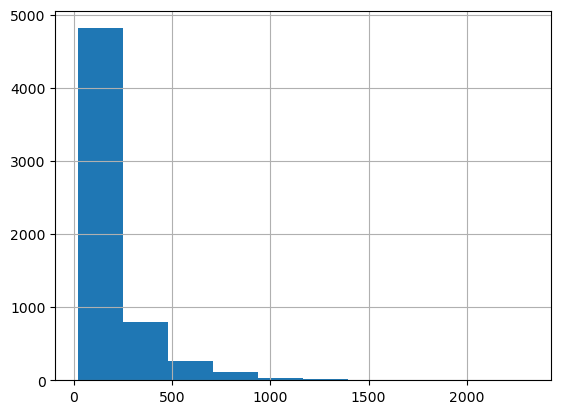

In [ ]:
interactions_per_user = ratings.groupby("user_id").size()
print(interactions_per_user.describe())
print(interactions_per_user.hist())

### BUILD INTERACTION MATRIX WITH TRAIN DATA


In [ ]:
def user_item_interaction_matrix(data,user_col_name,item_col_name,pref_col_name):
    num_users=len(data[user_col_name].unique())
    num_items=len(data[item_col_name].unique())

    user_sort=sorted(data[user_col_name].unique())
    item_sort=sorted(data[item_col_name].unique())

    item_index,user_index={},{}
    
    for idx in range(len(user_sort)):
        user_index[user_sort[idx]]=idx
        
    for idx in range(len(item_sort)):
        item_index[item_sort[idx]]=idx
    
    pref_matrix=np.zeros((num_users,num_items))
    
    for idx in range(len(data)):
        curr_user,curr_item,curr_pref=data[user_col_name].iloc[idx],data[item_col_name].iloc[idx],data[pref_col_name].iloc[idx]
        curr_user_idx,curr_item_idx=user_index[curr_user],item_index[curr_item]
        pref_matrix[curr_user_idx][curr_item_idx]=curr_pref
            
    return pref_matrix,user_index,item_index
        
pref_mat,user_index,item_index=user_item_interaction_matrix(train,"user_id","movie_id","rating")


In [ ]:
pref_mat.shape

(6040, 3666)

In [ ]:
def get_svd_embeddings(pref_mat,hidden_dim=100):
    U,S,Vt=np.linalg.svd(pref_mat)
    S_sqrt=np.sqrt(S)
    user_embedding=U[:,:hidden_dim]@S_sqrt
    item_embedding=(Vt.T)[:,:hidden_dim]@S_sqrt
    return user_embedding,item_embedding

In [ ]:
def get_sgd_embeddings(pref_mat,latent_dim,lr,max_iters,l_reg_user,l_reg_item):
    m,n=pref_mat.shape
    user_embedding=np.random.randn(m,latent_dim)*0.1
    item_embedding=np.random.randn(n,latent_dim)*0.1

    non_zer_val=[]
    for i in range(m):
        for j in range(n):
            if pref_mat[i][j]!=0:
                non_zer_val.append((i,j))
    
    for iter in tqdm(range(max_iters)):
        for idx in range(m*100):
            
            curr_user_idx,curr_item_idx=random.choice(non_zer_val)
            # curr_user,curr_item,curr_pref=user_embedding[curr_user_idx],item_embedding[curr_item_idx],pref_mat[curr_user_idx][curr_item_idx]
            
            residual=pref_mat[curr_user_idx][curr_item_idx] - (user_embedding[curr_user_idx].T@item_embedding[curr_item_idx])
            
            old_user = user_embedding[curr_user_idx].copy()
            user_embedding[curr_user_idx]=user_embedding[curr_user_idx] + lr*(residual)*item_embedding[curr_item_idx] - lr*l_reg_user*user_embedding[curr_user_idx]
            item_embedding[curr_item_idx]=item_embedding[curr_item_idx] + lr*(residual)*old_user - lr*l_reg_item*item_embedding[curr_item_idx]
			
    return user_embedding,item_embedding


# user_embedding,item_embedding=get_sgd_embeddings(pref_mat,750,0.01,40,0.1,0.1)

        

In [ ]:
def get_sgd_embeddings_bias(pref_mat,latent_dim,lr,max_iters,l_reg_user,l_reg_item,l_reg_user_bias,l_reg_item_bias):
    m,n=pref_mat.shape
    user_embedding=np.random.randn(m,latent_dim)*0.1
    item_embedding=np.random.randn(n,latent_dim)*0.1
    
    user_bias=np.random.randn(m)
    item_bias =np.random.randn(n)  
    global_bias=np.mean(pref_mat)
    
    global_bias=0
    non_zer_val=[]
    for i in range(m):
        for j in range(n):
            if pref_mat[i][j]!=0:
                non_zer_val.append((i,j))
                global_bias+=1
    
    global_bias=global_bias/len(non_zer_val)
    
    for iter in tqdm(range(max_iters)):
        for idx in range(m*100):
            
            curr_user_idx,curr_item_idx=random.choice(non_zer_val)
            # curr_user,curr_item,curr_pref=user_embedding[curr_user_idx],item_embedding[curr_item_idx],pref_mat[curr_user_idx][curr_item_idx]
            
            residual=pref_mat[curr_user_idx][curr_item_idx] - (user_embedding[curr_user_idx].T@item_embedding[curr_item_idx] + user_bias[curr_user_idx] + item_bias[curr_item_idx] + global_bias)
            
            old_user=user_embedding[curr_user_idx].copy()
            
            user_embedding[curr_user_idx]=user_embedding[curr_user_idx] + lr*(residual)*item_embedding[curr_item_idx] - lr*l_reg_user*user_embedding[curr_user_idx]
            item_embedding[curr_item_idx]=item_embedding[curr_item_idx] + lr*(residual)*old_user - lr*l_reg_item*item_embedding[curr_item_idx]
            user_bias[curr_user_idx]=user_bias[curr_user_idx] + lr*(residual) - lr*l_reg_user_bias*user_bias[curr_user_idx]
            item_bias[curr_item_idx]=item_bias[curr_item_idx] + lr*(residual) - lr*l_reg_item_bias*item_bias[curr_item_idx]

            
    return user_embedding,item_embedding,user_bias,item_bias,global_bias


user_embedding,item_embedding,user_bias,item_bias,global_bias=get_sgd_embeddings_bias(pref_mat,750,0.005,60,0.1,0.1,0.01,0.01)



        

100%|██████████| 60/60 [10:57<00:00, 10.96s/it]


In [ ]:
def evaluate(test,user_embeddings,item_embeddings,user_index,item_index,bias=False,global_bias=0,user_bias=0,item_bias=0):
    mse_arr,mae_arr=[],[]
    n=len(test)
    count=0

    for idx in range(n):
        user,item,rating=test.iloc[idx]["user_id"],test.iloc[idx]["movie_id"],test.iloc[idx]["rating"]
        
        if user not in user_index or item not in item_index:
            count+=1
            continue
        
        user_idx,item_idx=user_index[user],item_index[item]
        user_embedding,item_embedding=user_embeddings[user_idx],item_embeddings[item_idx]
        

        # print(user_bias,item_bias,global_bias)
        if bias:
            pred=user_embedding.T@item_embedding + global_bias + user_bias[user_idx] + item_bias[item_idx]
        else:
            pred=user_embedding.T@item_embedding    
        
        residual=np.pow(rating-pred,2)
        mse_arr.append(residual)

        mae_arr.append(np.abs(rating-pred))

    mse,mae=np.mean(mse_arr),np.mean(mae_arr)
    print(user_embedding,item_embedding)
    
    return mse,mae,count



evaluate(test,user_embedding,item_embedding,user_index,item_index,True,global_bias,user_bias,item_bias)

[ 2.14801171e-02 -2.30486196e-02 -1.74779966e-02 -2.26215052e-02
  1.52533872e-02  3.01321153e-02 -6.80162752e-03  9.58318451e-03
  3.27446599e-02 -3.65567002e-03 -6.75335392e-03 -1.26316677e-02
  1.04760191e-02 -1.48674648e-02  1.79281780e-02 -1.25538568e-03
  3.07911337e-02 -2.00690507e-02 -4.86384004e-04  1.22883116e-02
  2.70033943e-02 -4.20421556e-03 -1.13866775e-02 -1.48099671e-02
 -9.90709690e-03 -1.68617217e-02 -5.00380513e-03 -2.23660795e-02
  1.09281533e-02  2.44895982e-02  4.31855298e-02 -4.46950989e-03
  1.22026965e-02  4.71102638e-02  5.30488793e-03 -2.41661760e-02
 -2.06875321e-02 -3.02143881e-02 -6.92353865e-03 -1.34115533e-03
 -1.37556640e-02 -6.48550441e-03  8.31953243e-03  1.63132718e-02
  2.58927562e-03  2.16098170e-03 -1.36933291e-02 -2.73772207e-02
 -1.25455161e-02  3.65607622e-02 -5.11177450e-03 -1.61630587e-02
 -8.05096089e-03 -1.76480260e-02  1.11428774e-02  6.92293520e-03
 -2.14924676e-02 -1.84628027e-02  1.63064800e-03 -1.60208171e-02
 -3.29527922e-02 -2.08299

(np.float64(0.8655289039907847), np.float64(0.7362176869958289), 5)

In [ ]:
pred_mat=user_embedding@item_embedding.T
pred_mat.shape,np.max(pred_mat),np.min(pred_mat)

((6040, 3666), np.float64(5.79369763268381), np.float64(-0.6671120373515584))